In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




2026-05-18 19:31:23.271 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 19:31:23.597 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 19:31:23.599 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 19:31:23.603 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


2026-05-18 19:31:35.272 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'transmission_gate.gds'


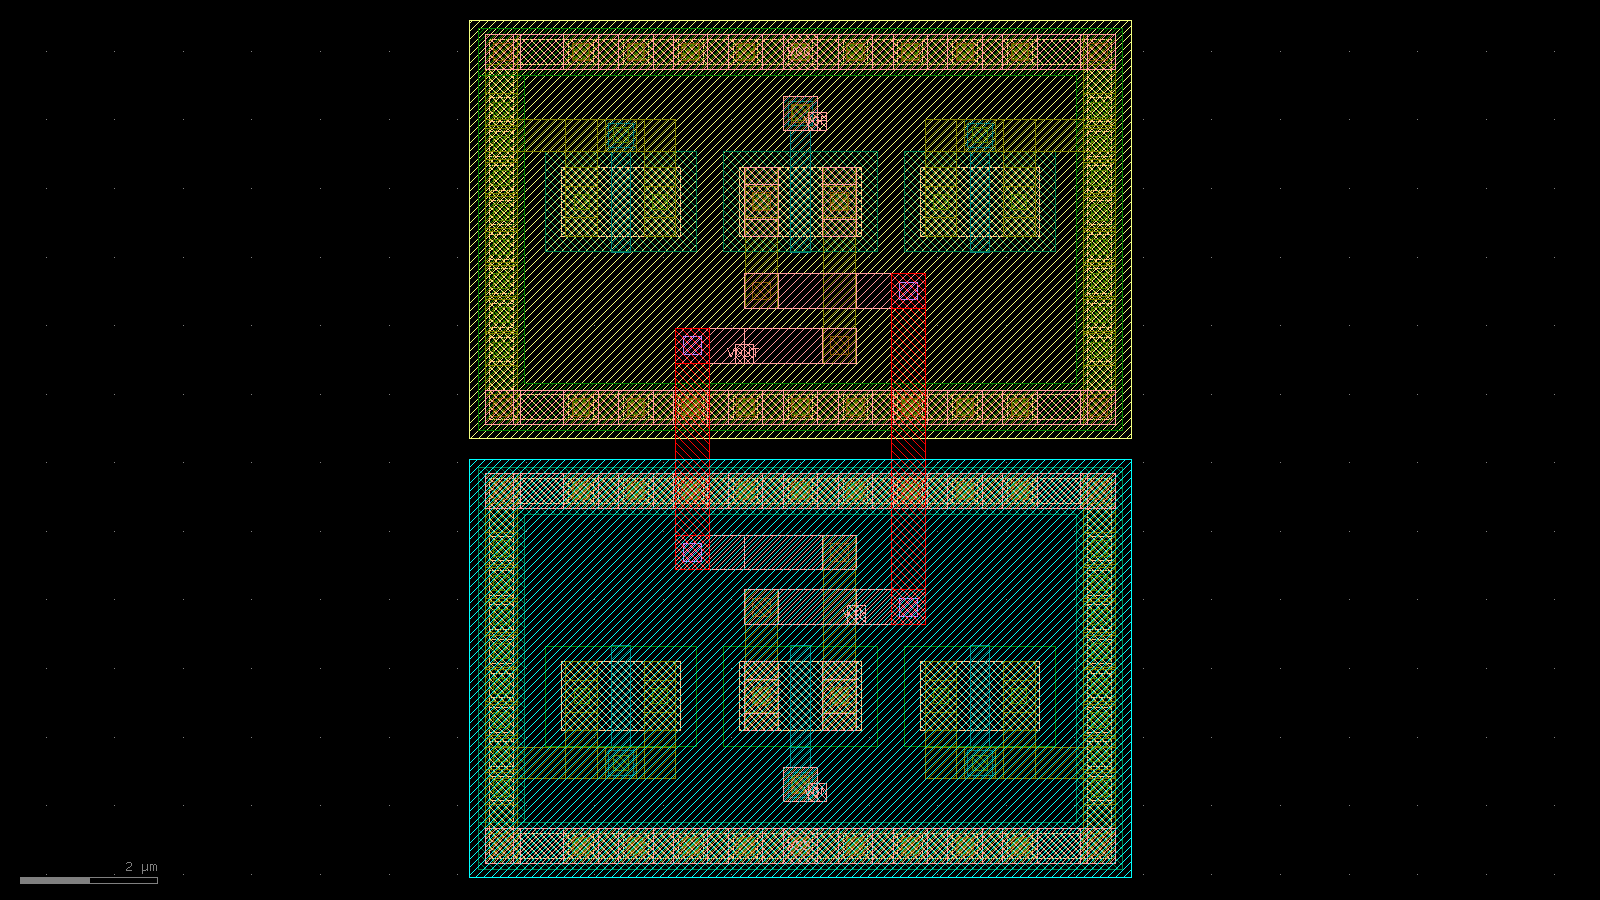

2026-05-18 19:31:35.340 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmppm9ixcyq/Transmission_Gate.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:35.572 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp2qx45e5v/Transmission_Gate.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmppm9ixcyq/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "Transmission_Gate".
[INFO]: Loa

Netgen 1.5.272 compiled on Mon May 18 06:54:31 AM WIB 2026
Reading netlist file /tmp/tmp2qx45e5v/Transmission_Gate_lvsmag.spice
Call to undefined subcircuit pfet_03v3
Creating placeholder cell definition.
Call to undefined subcircuit nfet_03v3
Creating placeholder cell definition.
Reading netlist file /tmp/tmp2qx45e5v/Transmission_Gate.spice
Call to undefined subcircuit pmos_3p3
Creating placeholder cell definition.
Call to undefined subcircuit nmos_3p3
Creating placeholder cell definition.
Call to undefined subcircuit nfet_03v3
Creating placeholder cell definition.
Call to undefined subcircuit pfet_03v3
Creating placeholder cell definition.

Reading setup file /home/irman/pdks/gf180mcuD/libs.tech/netgen/gf180mcuD_setup.tcl

No property area found for device c
Model nfet_03v3 pin 1 == 3
No property par1 found for device nfet_03v3
No property NRD found for device nfet_03v3
No property NRS found for device nfet_03v3
No property par found for device nfet_03v3
No property sa found for devi

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from glayout import MappedPDK
from glayout.pdk.gf180_mapped import gf180_mapped_pdk
from gdsfactory.cell import cell
from gdsfactory.component import Component
from gdsfactory import Component
from glayout.primitives.fet import nmos, pmos, multiplier
from glayout.util.comp_utils import evaluate_bbox, prec_center, align_comp_to_port, movex, movey
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.util.port_utils import rename_ports_by_orientation
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.primitives.guardring import tapring
from glayout.util.port_utils import add_ports_perimeter
from glayout.spice.netlist import Netlist
from glayout.primitives.via_gen import via_stack
from gdsfactory.components import text_freetype, rectangle
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

def add_tg_labels(tg_in: Component,
                        pdk: MappedPDK
                        ) -> Component:
	
    tg_in.unlock()
    
    # list that will contain all port/comp info
    move_info = list()
    # create labels and append to info list
    # vin
    vinlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    vinlabel.add_label(text="VIN",layer=pdk.get_glayer("met2_label"))
    move_info.append((vinlabel,tg_in.ports["N_multiplier_0_source_E"],None))
    
    # vout
    voutlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    voutlabel.add_label(text="VOUT",layer=pdk.get_glayer("met2_label"))
    move_info.append((voutlabel,tg_in.ports["P_multiplier_0_drain_W"],None))
    
    # vcc
    vcclabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.5,0.5),centered=True).copy()
    vcclabel.add_label(text="VCC",layer=pdk.get_glayer("met2_label"))
    move_info.append((vcclabel,tg_in.ports["P_tie_S_top_met_S"],None))
    
    # vss
    vsslabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.5,0.5),centered=True).copy()
    vsslabel.add_label(text="VSS",layer=pdk.get_glayer("met2_label"))
    move_info.append((vsslabel,tg_in.ports["N_tie_S_top_met_N"], None))
    
    # VGP
    vgplabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    vgplabel.add_label(text="VGP",layer=pdk.get_glayer("met2_label"))
    move_info.append((vgplabel,tg_in.ports["P_multiplier_0_gate_E"], None))
    
    # VGN
    vgnlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    vgnlabel.add_label(text="VGN",layer=pdk.get_glayer("met2_label"))
    move_info.append((vgnlabel,tg_in.ports["N_multiplier_0_gate_E"], None))

    # move everything to position
    for comp, prt, alignment in move_info:
        alignment = ('c','b') if alignment is None else alignment
        compref = align_comp_to_port(comp, prt, alignment=alignment)
        tg_in.add(compref)
    return tg_in.flatten() 


def get_component_netlist(component):
    """Helper function to get netlist object from component info, compatible with all gdsfactory versions"""
    from glayout.spice.netlist import Netlist
    
    # Try to get stored object first (for older gdsfactory versions)
    if 'netlist_obj' in component.info:
        return component.info['netlist_obj']
    
    # Try to reconstruct from netlist_data (for newer gdsfactory versions)
    if 'netlist_data' in component.info:
        data = component.info['netlist_data']
        netlist = Netlist(
            circuit_name=data['circuit_name'],
            nodes=data['nodes']
        )
        netlist.source_netlist = data['source_netlist']
        return netlist
    
    # Fallback: return the string representation (should not happen in normal operation)
    return component.info.get('netlist', '')

def gf180_mapped_pdk_add_tg_labels(tg_in: Component) -> Component:
	
    tg_in.unlock()
    
    # define layers`
    met1_pin = (68,16)
    met1_label = (68,5)
    li1_pin = (67,16)
    li1_label = (67,5)
    # list that will contain all port/comp info
    move_info = list()
    # create labels and append to info list
    # vin
    vinlabel = rectangle(layer=met1_pin,size=(0.27,0.27),centered=True).copy()
    vinlabel.add_label(text="VIN",layer=met1_label)
    move_info.append((vinlabel,tg_in.ports["N_multiplier_0_source_E"],None))
    
    # vout
    voutlabel = rectangle(layer=met1_pin,size=(0.27,0.27),centered=True).copy()
    voutlabel.add_label(text="VOUT",layer=met1_label)
    move_info.append((voutlabel,tg_in.ports["P_multiplier_0_drain_W"],None))
    
    # vcc
    vcclabel = rectangle(layer=met1_pin,size=(0.5,0.5),centered=True).copy()
    vcclabel.add_label(text="VCC",layer=met1_label)
    move_info.append((vcclabel,tg_in.ports["P_tie_S_top_met_S"],None))
    
    # vss
    vsslabel = rectangle(layer=met1_pin,size=(0.5,0.5),centered=True).copy()
    vsslabel.add_label(text="VSS",layer=met1_label)
    move_info.append((vsslabel,tg_in.ports["N_tie_S_top_met_N"], None))
    
    # VGP
    vgplabel = rectangle(layer=met1_pin,size=(0.27,0.27),centered=True).copy()
    vgplabel.add_label(text="VGP",layer=met1_label)
    move_info.append((vgplabel,tg_in.ports["P_multiplier_0_gate_E"], None))
    
    # VGN
    vgnlabel = rectangle(layer=met1_pin,size=(0.27,0.27),centered=True).copy()
    vgnlabel.add_label(text="VGN",layer=met1_label)
    move_info.append((vgnlabel,tg_in.ports["N_multiplier_0_gate_E"], None))

    # move everything to position
    for comp, prt, alignment in move_info:
        alignment = ('c','b') if alignment is None else alignment
        compref = align_comp_to_port(comp, prt, alignment=alignment)
        tg_in.add(compref)
    return tg_in.flatten() 


def tg_netlist(nfet: Component, pfet: Component) -> Netlist:

         netlist = Netlist(circuit_name='Transmission_Gate', nodes=['VIN', 'VSS', 'VOUT', 'VCC', 'VGP', 'VGN'])
         # Use helper function to get netlist objects regardless of gdsfactory version
         nfet_netlist = get_component_netlist(nfet)
         pfet_netlist = get_component_netlist(pfet)
         netlist.connect_netlist(nfet_netlist, [('D', 'VOUT'), ('G', 'VGN'), ('S', 'VIN'), ('B', 'VSS')])
         netlist.connect_netlist(pfet_netlist, [('D', 'VOUT'), ('G', 'VGP'), ('S', 'VIN'), ('B', 'VCC')])

         return netlist

@cell
def  transmission_gate(
        pdk: MappedPDK,
        width: tuple[float,float] = (1,1),
        length: tuple[float,float] = (None,None),
        fingers: tuple[int,int] = (1,1),
        multipliers: tuple[int,int] = (1,1),
        substrate_tap: bool = False,
        tie_layers: tuple[str,str] = ("met2","met1"),
        **kwargs
        ) -> Component:
    """
    creates a transmission gate
    tuples are in (NMOS,PMOS) order
    **kwargs are any kwarg that is supported by nmos and pmos
    """
   
    #top level component
    top_level = Component(name="transmission_gate")

    #two fets
    nfet = nmos(pdk, width=width[0], fingers=fingers[0], multipliers=multipliers[0], with_dummy=True, with_dnwell=False,  with_substrate_tap=False, length=length[0], **kwargs)
    pfet = pmos(pdk, width=width[1], fingers=fingers[1], multipliers=multipliers[1], with_dummy=True, with_substrate_tap=False, length=length[1], **kwargs)
    nfet_ref = top_level << nfet
    pfet_ref = top_level << pfet 
    pfet_ref = rename_ports_by_orientation(pfet_ref.mirror_y())

    #Relative move
    pfet_ref.movey(nfet_ref.ymax + evaluate_bbox(pfet_ref)[1]/2 + pdk.util_max_metal_seperation())
    
    #Routing
    top_level << c_route(pdk, nfet_ref.ports["multiplier_0_source_E"], pfet_ref.ports["multiplier_0_source_E"])
    top_level << c_route(pdk, nfet_ref.ports["multiplier_0_drain_W"], pfet_ref.ports["multiplier_0_drain_W"], viaoffset=False)
    
    #Renaming Ports
    top_level.add_ports(nfet_ref.get_ports_list(), prefix="N_")
    top_level.add_ports(pfet_ref.get_ports_list(), prefix="P_")

    #substrate tap
    if substrate_tap:
            substrate_tap_encloses =((evaluate_bbox(top_level)[0]+pdk.util_max_metal_seperation()), (evaluate_bbox(top_level)[1]+pdk.util_max_metal_seperation()))
            guardring_ref = top_level << tapring(
            pdk,
            enclosed_rectangle=substrate_tap_encloses,
            sdlayer="p+s/d",
            horizontal_glayer='met2',
            vertical_glayer='met1',
        )
            guardring_ref.move(nfet_ref.center).movey(evaluate_bbox(pfet_ref)[1]/2 + pdk.util_max_metal_seperation()/2)
            top_level.add_ports(guardring_ref.get_ports_list(),prefix="tap_")
    
    component = component_snap_to_grid(rename_ports_by_orientation(top_level)) 
    # Store netlist as string to avoid gymnasium info dict type restrictions
    # Compatible with both gdsfactory 7.7.0 and 7.16.0+ strict Pydantic validation
    netlist_obj = tg_netlist(nfet, pfet)
    component.info['netlist'] = netlist_obj.generate_netlist()
    # Store the Netlist object for hierarchical netlist building
    component.info['netlist_obj'] = netlist_obj
    # Store serialized netlist data for reconstruction if needed
    component.info['netlist_data'] = {
        'circuit_name': netlist_obj.circuit_name,
        'nodes': netlist_obj.nodes,
        'source_netlist': netlist_obj.source_netlist
    }


    return component
if __name__ == "__main__":
    # OLD EVAL CODE
    # comp = transmission_gate(gf180_mapped_pdk)
    # # comp.pprint_ports()
    # comp = add_tg_labels(comp,gf180_mapped_pdk)
    # comp.name = "TG"
    # pass # comp.show()
    # #print(comp.info['netlist'].generate_netlist())
    # print("...Running DRC...")
    # pass # drc_result = gf180_mapped_pdk.drc_magic(comp, "TG")
    # ## Klayout DRC
    # #drc_result = gf180.drc(comp)\n
    
    # time.sleep(5)
        
    # print("...Running LVS...")
    # pass # lvs_res=gf180_mapped_pdk.lvs_netgen(comp, "TG")
    # #print("...Saving GDS...")
    # #comp.write_gds('out_TG.gds')

    # NEW EVAL CODE
    #transmission_gate = transmission_gate(gf180_mapped_pdk)
    transmission_gate = add_tg_labels(transmission_gate(gf180_mapped_pdk),gf180_mapped_pdk)
    pass # transmission_gate.show()
    transmission_gate.name = "Transmission_Gate"
    #pass # magic_drc_result = gf180_mapped_pdk.drc_magic(transmission_gate, transmission_gate.name)
    #pass # netgen_lvs_result = gf180_mapped_pdk.lvs_netgen(transmission_gate, transmission_gate.name)
    transmission_gate_gds = transmission_gate.write_gds("transmission_gate.gds")
    pass # res = run_evaluation("transmission_gate.gds", transmission_gate.name, transmission_gate)


# Show the generated GDS
show_gds("transmission_gate.gds")

comp = transmission_gate
# DRC with magic (graceful if magic not installed)
try:
    drc_result = gf180_mapped_pdk.drc_magic(comp, comp.name)
    print('DRC:', drc_result)
except Exception as e:
    print(f'DRC skipped: {e}')
# LVS with netgen (graceful if netgen not installed)
try:
    lvs_result = gf180_mapped_pdk.lvs_netgen(comp, comp.name)
    print('LVS:', lvs_result['result_str'])
except Exception as e:
    print(f'LVS skipped: {e}')


In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("transmission_gate.gds", comp.name, comp)
    print(result)


--- Starting Comprehensive Evaluation for Transmission_Gate ---
Cleaning up intermediate files for component 'Transmission_Gate'...
  - Deleted: Transmission_Gate.res.ext
  - Deleted directory: Transmission_Gate_lvs_out
  - Deleted: Transmission_Gate.nodes
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:36.077 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp8j5cdvxv/Transmission_Gate.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpcxost_t0/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "Transmission_Gate".
[INFO]: Loa

Netgen 1.5.272 compiled on Mon May 18 06:54:31 AM WIB 2026
Reading netlist file /tmp/tmp8j5cdvxv/Transmission_Gate_lvsmag.spice
Call to undefined subcircuit pfet_03v3
Creating placeholder cell definition.
Call to undefined subcircuit nfet_03v3
Creating placeholder cell definition.
Reading netlist file /tmp/tmp8j5cdvxv/Transmission_Gate.spice
Call to undefined subcircuit pmos_3p3
Creating placeholder cell definition.
Call to undefined subcircuit nmos_3p3
Creating placeholder cell definition.
Call to undefined subcircuit nfet_03v3
Creating placeholder cell definition.
Call to undefined subcircuit pfet_03v3
Creating placeholder cell definition.

Reading setup file /home/irman/pdks/gf180mcuD/libs.tech/netgen/gf180mcuD_setup.tcl

No property area found for device c
Model nfet_03v3 pin 1 == 3
No property par1 found for device nfet_03v3
No property NRD found for device nfet_03v3
No property NRS found for device nfet_03v3
No property par found for device nfet_03v3
No property sa found for devi

--- Evaluation complete. Results saved to Transmission_Gate_2.json ---
{'component_name': 'Transmission_Gate', 'timestamp': '2026-05-18T19:31:36.740908', 'drc_lvs_fail': True, 'drc': {'status': 'fail', 'is_pass': False, 'report_path': '/home/irman/Gelochip/notebooks/datasets/transmission_gate/Transmission_Gate_drc_out/drc/Transmission_Gate/Transmission_Gate.rpt', 'summary': {'is_pass': False, 'total_errors': 2, 'error_details': [{'rule': 'Metal2 width < 0.28um (M2.1)', 'details': '0.250um 8.115um 0.385um 8.125um'}, {'rule': 'Metal2 width < 0.28um (M2.1)', 'details': '0.250um -1.675um 0.385um -1.665um'}]}}, 'lvs': {'status': 'pass', 'is_pass': True, 'report_path': '/home/irman/Gelochip/notebooks/datasets/transmission_gate/Transmission_Gate_lvs_out/lvs/Transmission_Gate/Transmission_Gate_lvs.rpt', 'summary': {'is_pass': True, 'conclusion': 'LVS Pass: Netlists match.', 'total_mismatches': 0, 'mismatch_details': {'nets': '6                          |Number of nets: 6', 'devices': '4       

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(transmission_gate, label='transmission_gate')


Circuit : Transmission_Gate
Nodes   : ['VIN', 'VSS', 'VOUT', 'VCC', 'VGP', 'VGN']

── DC Operating Point: transmission_gate ──

	Node                                  Voltage
	----                                  -------
	----	-------
	n_vgn                            3.300000e+00
	n_vgp                            0.000000e+00
	n_vout                           1.697058e+00
	n_vin                            1.650000e+00
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
